In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# TensorFlow & Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import os
%matplotlib inline

# Set random seed for reproducibility
np.random.seed(1)
print("TensorFlow version:", tf.__version__)
print("All imports successful ✅")

TensorFlow version: 2.19.0
All imports successful ✅


In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"priyamdutta2","key":"6451f9e0f7ea50d511a8a10a1a45f352"}'}

In [4]:
#configure kaggle
# Move kaggle.json to the correct directory
# and set permissions so Kaggle CLI can read it
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)
print("Kaggle API configured ✅")

Kaggle API configured ✅


In [5]:
# Download FER2013 dataset from Kaggle
# Contains 35,887 grayscale 48x48 facial images
# across 7 emotion classes
!kaggle datasets download -d msambare/fer2013

# Unzip into fer2013/ folder
!unzip fer2013.zip -d fer2013
print("Dataset downloaded ✅")

Streaming output truncated to the last 5000 lines.
  inflating: fer2013/train/sad/Training_65267116.jpg  
  inflating: fer2013/train/sad/Training_65275626.jpg  
  inflating: fer2013/train/sad/Training_6529266.jpg  
  inflating: fer2013/train/sad/Training_65329617.jpg  
  inflating: fer2013/train/sad/Training_65338712.jpg  
  inflating: fer2013/train/sad/Training_65338797.jpg  
  inflating: fer2013/train/sad/Training_65387162.jpg  
  inflating: fer2013/train/sad/Training_65404494.jpg  
  inflating: fer2013/train/sad/Training_65426218.jpg  
  inflating: fer2013/train/sad/Training_65430136.jpg  
  inflating: fer2013/train/sad/Training_65437377.jpg  
  inflating: fer2013/train/sad/Training_6545735.jpg  
  inflating: fer2013/train/sad/Training_65463385.jpg  
  inflating: fer2013/train/sad/Training_65473985.jpg  
  inflating: fer2013/train/sad/Training_65502829.jpg  
  inflating: fer2013/train/sad/Training_65505359.jpg  
  inflating: fer2013/train/sad/Training_65508578.jpg  
  inflating: fer

In [6]:
# =============================================
# DATA PREPROCESSING
# No augmentation here — we'll build it
# directly into the model as layers instead
# =============================================

# Only normalize pixel values (0-255 → 0-1)
# Augmentation is handled inside the model
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2        # 20% of train → validation
)

# Only normalize test data
test_datagen = ImageDataGenerator(rescale=1./255)

# Load training set
train_generator = train_datagen.flow_from_directory(
    'fer2013/train',
    target_size=(48, 48),       # FER2013 standard image size
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Load validation set
val_generator = train_datagen.flow_from_directory(
    'fer2013/train',
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Load test set
test_generator = test_datagen.flow_from_directory(
    'fer2013/test',
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Class indices: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [7]:
# =============================================
# DATA PREPROCESSING
# =============================================

# Only normalize pixel values (0-255 → 0-1)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2        # 20% of train → validation
)

# Only normalize test data
test_datagen = ImageDataGenerator(rescale=1./255)

# Load training set
train_generator = train_datagen.flow_from_directory(
    'fer2013/train',
    target_size=(48, 48),       # FER2013 standard image size
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Load validation set
val_generator = train_datagen.flow_from_directory(
    'fer2013/train',
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Load test set
test_generator = test_datagen.flow_from_directory(
    'fer2013/test',
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Class indices: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [8]:
# =============================================
# CLASS WEIGHTS
# Fix class imbalance — Focused on Disgust
# samples vs Happy's ~8000. Tune the model to tell it that
# "getting Disgust wrong is more costly!"
# =============================================

from sklearn.utils.class_weight import compute_class_weight

# Get all training labels
train_labels = train_generator.classes

# Automatically compute weights inversely proportional to class frequency
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Convert to dictionary {class_index: weight}
class_weight_dict = dict(enumerate(class_weights))

print("Class weights:")
class_names = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']
for i, (cls, weight) in enumerate(class_weight_dict.items()):
    print(f"  {class_names[i]}: {weight:.2f}")

Class weights:
  Angry: 1.03
  Disgust: 9.40
  Fear: 1.00
  Happy: 0.57
  Neutral: 0.83
  Sad: 0.85
  Surprise: 1.29


In [9]:
# =============================================
# V2 MODEL ARCHITECTURE
# Improvements over V1:
# 1. Augmentation layers built into model
# 2. Deeper architecture (4 blocks vs 3)
# 3. More filters in each block
# =============================================

model = Sequential([

    # ---- AUGMENTATION BLOCK ----
    # Only active during training, ignored at test time
    layers.Input(shape=(48, 48, 1)),
    layers.RandomFlip("horizontal"),        # randomly flip faces horizontally
    layers.RandomRotation(0.15),            # randomly rotate up to 15%
    layers.RandomZoom(0.15),               # randomly zoom in/out
    layers.RandomTranslation(0.1, 0.1),    # randomly shift up/down/left/right

    # ---- BLOCK 1 (32 filters) ----
    # Detects basic edges and lines
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),

    # ---- BLOCK 2 (64 filters) ----
    # Detects eyes, nose, mouth shapes
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),

    # ---- BLOCK 3 (128 filters) ----
    # Detects facial expressions
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),

    # ---- BLOCK 4 (256 filters) ----
    # NEW in V2! Detects complex emotion combinations
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),

    # ---- FULLY CONNECTED ----
    layers.Flatten(),
    layers.Dense(512, activation='relu'),   # bigger than V1's 256
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),   # extra dense layer vs V1
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(7, activation='softmax')   # 7 emotion classes
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 48, 48, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 48, 48, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             

 Total params: 2,491,879 (9.51 MB)

 Trainable params: 2,488,423 (9.49 MB)

 Non-trainable params: 3,456 (13.50 KB)

In [10]:
# =============================================
# COMPILE & TRAIN
# Improvements over V1:
# 1. Class weights to fix Disgust/Fear imbalance
# 2. 50 epochs instead of 30
# 3. Slightly lower initial learning rate
# =============================================

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,              # more patience than V1's 5
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Train with class weights!
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    class_weight=class_weight_dict,  # NEW in V2!
    callbacks=[early_stop, reduce_lr]
)

# Save immediately after training
model.save('mood_model_v2.h5')
print("V2 Model saved! ✅")

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


359/359 ━━━━━━━━━━━━━━━━━━━━ 33s 57ms/step - accuracy: 0.1501 - loss: 2.4964 - val_accuracy: 0.0986 - val_loss: 2.0486 - learning_rate: 0.0010
Epoch 2/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.1632 - loss: 2.0694 - val_accuracy: 0.1980 - val_loss: 1.9732 - learning_rate: 0.0010
Epoch 3/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.1732 - loss: 1.9642 - val_accuracy: 0.2190 - val_loss: 1.8555 - learning_rate: 0.0010
Epoch 4/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - accuracy: 0.1850 - loss: 1.9050 - val_accuracy: 0.2014 - val_loss: 1.8861 - learning_rate: 0.0010
Epoch 5/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.1816 - loss: 1.9058 - val_accuracy: 0.2618 - val_loss: 1.8083 - learning_rate: 0.0010
Epoch 6/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.2081 - loss: 1.8708 - val_accuracy: 0.1794 - val_loss: 1.9150 - learning_rate: 0.0010
Epoch 7/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.2016 - loss: 1.8840

V2 Model saved! ✅


In [11]:
# Evaluate V2 on unseen test data
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"V2 Test Accuracy: {test_accuracy*100:.2f}%")
print(f"V2 Test Loss: {test_loss:.4f}")

113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.5184 - loss: 1.2322
V2 Test Accuracy: 55.70%
V2 Test Loss: 1.1760


113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step


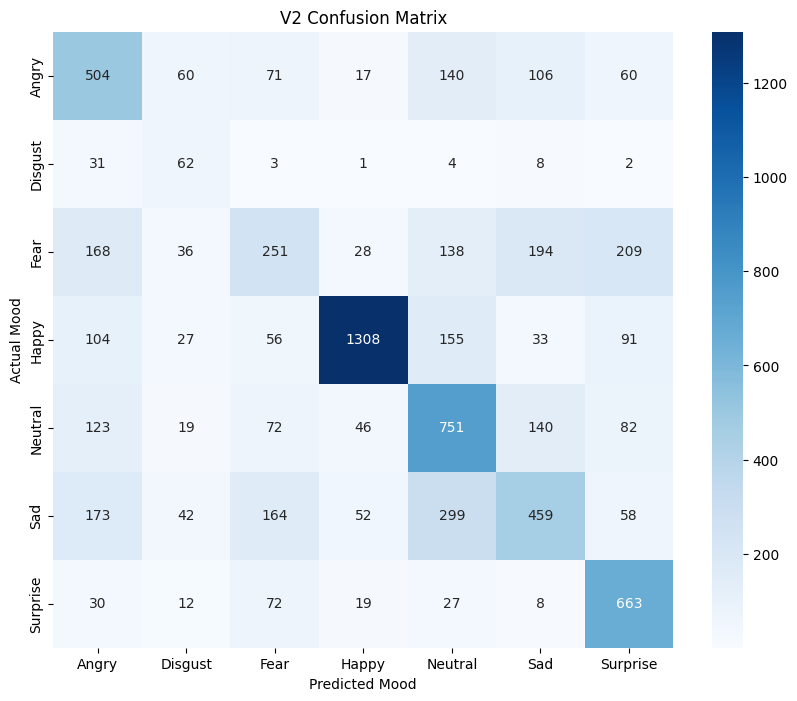

In [12]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

class_names = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']

y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('V2 Confusion Matrix')
plt.ylabel('Actual Mood')
plt.xlabel('Predicted Mood')
plt.show()